# Environment Setup: Install required packages (OpenCV, tqdm, scikit-image)

In [2]:
pip install opencv-python tqdm scikit-image

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 104.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 101.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-image] [scikit-image]]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Imports + Global Configuration: DATA_ROOT, SEED, MAX_GROUPS, regex for pairing

In [5]:
import re, random
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm

DATA_ROOT = Path("vault")   # <-- set to your vault folder containing 0001..4000
SEED = 42
MAX_GROUPS = 1000

PAIR_RE = re.compile(r"(?:c|cf)-(\d+)-(\d+)\.jpg$", re.IGNORECASE)

def split_groups(train=0.8, val=0.1, max_groups=MAX_GROUPS):
    group_dirs = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])
    group_dirs = group_dirs[:max_groups]
    rng = random.Random(SEED)
    rng.shuffle(group_dirs)

    n = len(group_dirs)
    n_train = int(train*n)
    n_val = int(val*n)
    return group_dirs[:n_train], group_dirs[n_train:n_train+n_val], group_dirs[n_train+n_val:]

def build_pix2pix_pairs_for_group_duplicates(gdir: Path, max_k=60):
    # idx -> list(paths) to handle duplicates like 1-48 repeated
    idx_to_paths = defaultdict(list)
    for p in sorted(gdir.glob("*.jpg")):
        m = PAIR_RE.search(p.name)
        if m:
            idx = int(m.group(2))
            idx_to_paths[idx].append(p)
    for idx in idx_to_paths:
        idx_to_paths[idx].sort(key=lambda x: x.name)

    pairs = []
    for k in range(1, max_k, 2):
        cleans  = idx_to_paths.get(k, [])
        noisies = idx_to_paths.get(k+1, [])
        n = min(len(cleans), len(noisies))
        for i in range(n):
            pairs.append((str(noisies[i]), str(cleans[i])))
    return pairs

def build_split_pairs(group_list, desc):
    pairs = []
    for gdir in tqdm(group_list, desc=desc):
        pairs.extend(build_pix2pix_pairs_for_group_duplicates(gdir))
    return pairs

train_g, val_g, test_g = split_groups(max_groups=MAX_GROUPS)
pix_train = build_split_pairs(train_g, "Pairing TRAIN")
pix_val   = build_split_pairs(val_g,   "Pairing VAL")
pix_test  = build_split_pairs(test_g,  "Pairing TEST")

len(pix_train), len(pix_val), len(pix_test)

Pairing TRAIN:   0%|          | 0/800 [00:00<?, ?it/s]

Pairing VAL:   0%|          | 0/100 [00:00<?, ?it/s]

Pairing TEST:   0%|          | 0/100 [00:00<?, ?it/s]

(43146, 5400, 5400)

# Group Splitting: Deterministic train/val/test partition of dataset folders

In [6]:
import tensorflow as tf

IMG_SIZE = (512, 512)
BATCH_SIZE = 4

def read_rgb_01(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    img = tf.cast(img, tf.float32) / 255.0
    return img

def make_pix2pix_dataset(pairs, training=True):
    noisy_paths = [p[0] for p in pairs]
    clean_paths = [p[1] for p in pairs]
    ds = tf.data.Dataset.from_tensor_slices((noisy_paths, clean_paths))

    if training:
        ds = ds.shuffle(min(len(pairs), 2000), seed=SEED, reshuffle_each_iteration=True)

    def _load(noisy_p, clean_p):
        x = read_rgb_01(noisy_p)
        y = read_rgb_01(clean_p)
        # scale to [-1,1] for tanh generator
        x = x * 2.0 - 1.0
        y = y * 2.0 - 1.0
        return x, y

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=training).prefetch(tf.data.AUTOTUNE)
    return ds

pix_train_ds = make_pix2pix_dataset(pix_train, training=True)
pix_val_ds   = make_pix2pix_dataset(pix_val,   training=False)
pix_test_ds  = make_pix2pix_dataset(pix_test,  training=False)

xb, yb = next(iter(pix_train_ds))
xb.shape, yb.shape, xb.dtype, yb.dtype

E0000 00:00:1770288773.556604     371 ptx_compiler_helpers.cc:88] *** WARNING *** Invoking ptxas with version 12.3.107, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


(TensorShape([4, 512, 512, 3]),
 TensorShape([4, 512, 512, 3]),
 tf.float32,
 tf.float32)

# Visual Sanity Check: Display example (noisy → clean) training pairs

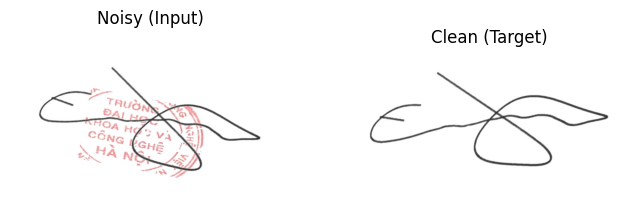

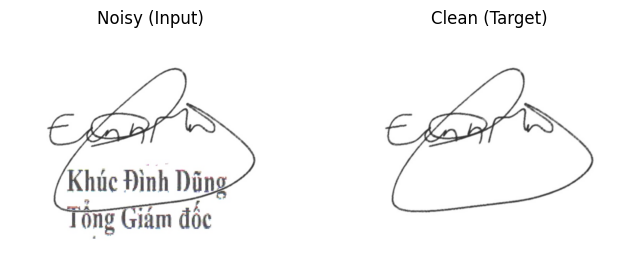

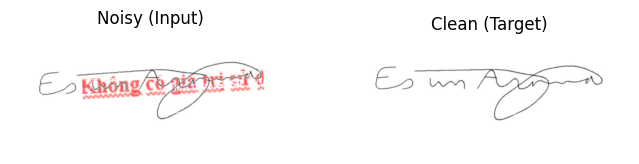

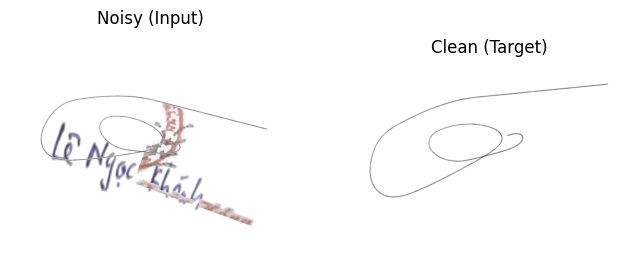

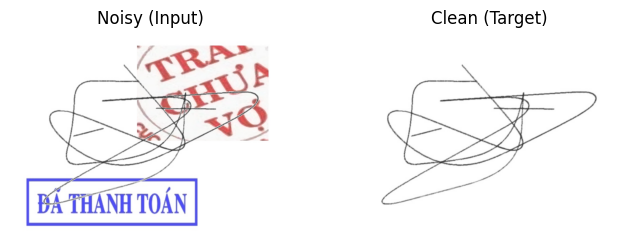

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def show_pix2pix_pair(pair):
    noisy_path, clean_path = pair
    noisy = Image.open(noisy_path).convert("RGB")
    clean = Image.open(clean_path).convert("RGB")

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1); plt.imshow(noisy); plt.title("Noisy (Input)"); plt.axis("off")
    plt.subplot(1,2,2); plt.imshow(clean); plt.title("Clean (Target)"); plt.axis("off")
    plt.show()

# Show 5 random training pairs
for _ in range(5):
    show_pix2pix_pair(random.choice(pix_train))

# Pix2Pix Architecture: U-Net Generator + PatchGAN Discriminator (TensorFlow)

In [7]:
def downsample(filters, size, apply_batchnorm=True):
    init = tf.random_normal_initializer(0., 0.02)
    seq = tf.keras.Sequential()
    seq.add(tf.keras.layers.Conv2D(filters, size, strides=2, padding='same',
                                   kernel_initializer=init, use_bias=False))
    if apply_batchnorm:
        seq.add(tf.keras.layers.BatchNormalization())
    seq.add(tf.keras.layers.LeakyReLU())
    return seq

def upsample(filters, size, apply_dropout=False):
    init = tf.random_normal_initializer(0., 0.02)
    seq = tf.keras.Sequential()
    seq.add(tf.keras.layers.Conv2DTranspose(filters, size, strides=2, padding='same',
                                            kernel_initializer=init, use_bias=False))
    seq.add(tf.keras.layers.BatchNormalization())
    if apply_dropout:
        seq.add(tf.keras.layers.Dropout(0.5))
    seq.add(tf.keras.layers.ReLU())
    return seq

def Generator():
    inputs = tf.keras.layers.Input(shape=[IMG_SIZE[0], IMG_SIZE[1], 3])

    down_stack = [
        downsample(64, 4, apply_batchnorm=False),
        downsample(128, 4),
        downsample(256, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
    ]
    up_stack = [
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4),
        upsample(256, 4),
        upsample(128, 4),
        upsample(64, 4),
    ]

    init = tf.random_normal_initializer(0., 0.02)
    last = tf.keras.layers.Conv2DTranspose(3, 4, strides=2, padding='same',
                                           kernel_initializer=init,
                                           activation='tanh',
                                           dtype="float32")

    x = inputs
    skips = []
    for down in down_stack:
        x = down(x); skips.append(x)
    skips = reversed(skips[:-1])
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = tf.keras.layers.Concatenate()([x, skip])

    x = last(x)
    return tf.keras.Model(inputs, x, name="pix2pix_generator")

def Discriminator():
    init = tf.random_normal_initializer(0., 0.02)
    inp = tf.keras.layers.Input(shape=[IMG_SIZE[0], IMG_SIZE[1], 3], name='input')
    tar = tf.keras.layers.Input(shape=[IMG_SIZE[0], IMG_SIZE[1], 3], name='target')
    x = tf.keras.layers.Concatenate()([inp, tar])

    down1 = downsample(64, 4, False)(x)
    down2 = downsample(128, 4)(down1)
    down3 = downsample(256, 4)(down2)

    zero_pad1 = tf.keras.layers.ZeroPadding2D()(down3)
    conv = tf.keras.layers.Conv2D(512, 4, strides=1, kernel_initializer=init, use_bias=False)(zero_pad1)
    bn1 = tf.keras.layers.BatchNormalization()(conv)
    leaky = tf.keras.layers.LeakyReLU()(bn1)

    zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky)
    last = tf.keras.layers.Conv2D(1, 4, strides=1, kernel_initializer=init)(zero_pad2)
    return tf.keras.Model([inp, tar], last, name="pix2pix_discriminator")

generator = Generator()
discriminator = Discriminator()

# Losses + Optimizers + Training Step

In [8]:
loss_obj = tf.keras.losses.BinaryCrossentropy(from_logits=True)
LAMBDA = 100.0

def disc_loss(d_real, d_fake):
    real = loss_obj(tf.ones_like(d_real), d_real)
    fake = loss_obj(tf.zeros_like(d_fake), d_fake)
    return real + fake

def gen_gan_loss(d_fake):
    return loss_obj(tf.ones_like(d_fake), d_fake)

def gen_l1_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return tf.reduce_mean(tf.abs(y_true - y_pred))

gen_opt  = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
disc_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

@tf.function
def train_step(x, y):
    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        y_pred = generator(x, training=True)
        d_real = discriminator([x, y], training=True)
        d_fake = discriminator([x, y_pred], training=True)

        g_gan = gen_gan_loss(d_fake)
        g_l1  = gen_l1_loss(y, y_pred)
        g_tot = g_gan + LAMBDA * g_l1

        d_tot = disc_loss(d_real, d_fake)

    g_grads = gt.gradient(g_tot, generator.trainable_variables)
    d_grads = dt.gradient(d_tot, discriminator.trainable_variables)
    gen_opt.apply_gradients(zip(g_grads, generator.trainable_variables))
    disc_opt.apply_gradients(zip(d_grads, discriminator.trainable_variables))
    return g_tot, g_gan, g_l1, d_tot

def fit_pix2pix(train_ds, epochs=5, save_every=1):
    for ep in range(1, epochs+1):
        pbar = tqdm(train_ds, desc=f"Epoch {ep}/{epochs}")
        for x, y in pbar:
            g_tot, g_gan, g_l1, d_tot = train_step(x, y)
            pbar.set_postfix({
                "g": float(tf.reduce_mean(g_tot).numpy()),
                "l1": float(tf.reduce_mean(g_l1).numpy()),
                "d": float(tf.reduce_mean(d_tot).numpy()),
            })
        if ep % save_every == 0:
            generator.save(f"pix2pix_gen_e{ep}.keras", include_optimizer=False)

fit_pix2pix(pix_train_ds, epochs=3, save_every=1)

Epoch 1/3:   0%|          | 0/10786 [00:00<?, ?it/s]

2026-02-05 10:53:41.954146: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Epoch 2/3:   0%|          | 0/10786 [00:00<?, ?it/s]

Epoch 3/3:   0%|          | 0/10786 [00:00<?, ?it/s]

# Qualitative Samples: Visualize generator outputs on a batch from the dataset

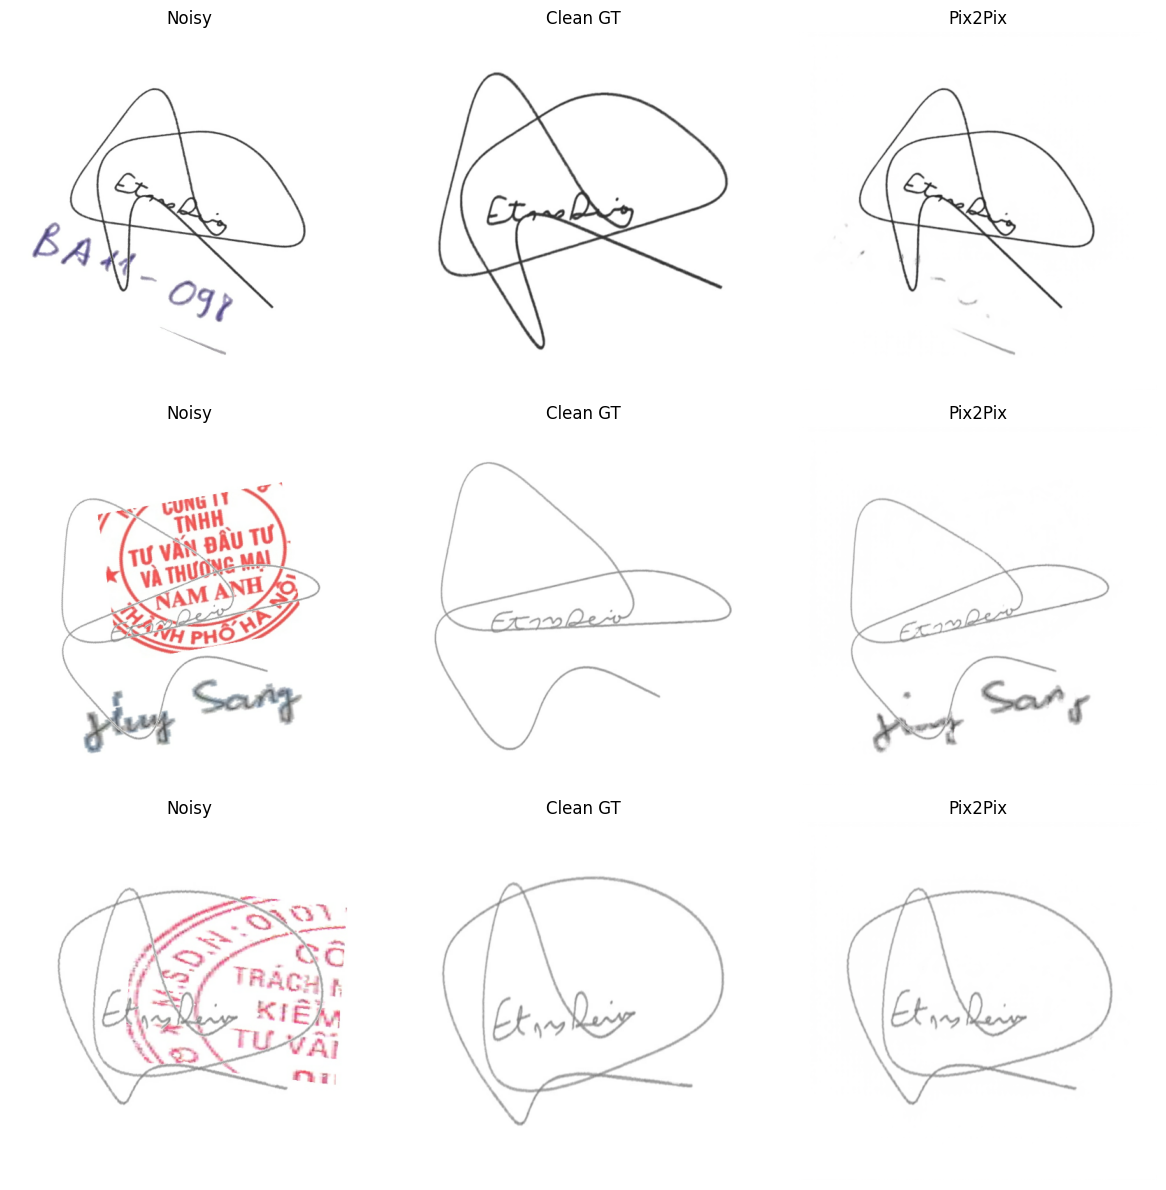

PSNR: 29.63417667388916 +/- 5.555431548568872
SSIM: 0.9332941913604736 +/- 0.03461715972997422


In [9]:
import numpy as np
import matplotlib.pyplot as plt

def denorm01(x): return (x + 1.0) / 2.0

def show_samples(ds, n=3):
    x, y = next(iter(ds))
    y_pred = generator(x, training=False)

    x0 = denorm01(x).numpy()
    y0 = denorm01(y).numpy()
    yp = denorm01(y_pred).numpy()

    n = min(n, x.shape[0])
    plt.figure(figsize=(12, 4*n))
    for i in range(n):
        plt.subplot(n,3,3*i+1); plt.imshow(x0[i]); plt.title("Noisy"); plt.axis("off")
        plt.subplot(n,3,3*i+2); plt.imshow(y0[i]); plt.title("Clean GT"); plt.axis("off")
        plt.subplot(n,3,3*i+3); plt.imshow(yp[i]); plt.title("Pix2Pix"); plt.axis("off")
    plt.tight_layout(); plt.show()

show_samples(pix_val_ds, n=3)

def eval_psnr_ssim(ds, n_batches=50):
    psnrs, ssims = [], []
    for i, (x, y) in enumerate(ds):
        if i >= n_batches: break
        y_pred = generator(x, training=False)
        y0 = denorm01(y)
        yp = denorm01(y_pred)
        psnrs.append(float(tf.reduce_mean(tf.image.psnr(y0, yp, max_val=1.0)).numpy()))
        ssims.append(float(tf.reduce_mean(tf.image.ssim(y0, yp, max_val=1.0)).numpy()))
    print("PSNR:", np.mean(psnrs), "+/-", np.std(psnrs))
    print("SSIM:", np.mean(ssims), "+/-", np.std(ssims))

eval_psnr_ssim(pix_test_ds, n_batches=50)

# Single-Image Inference

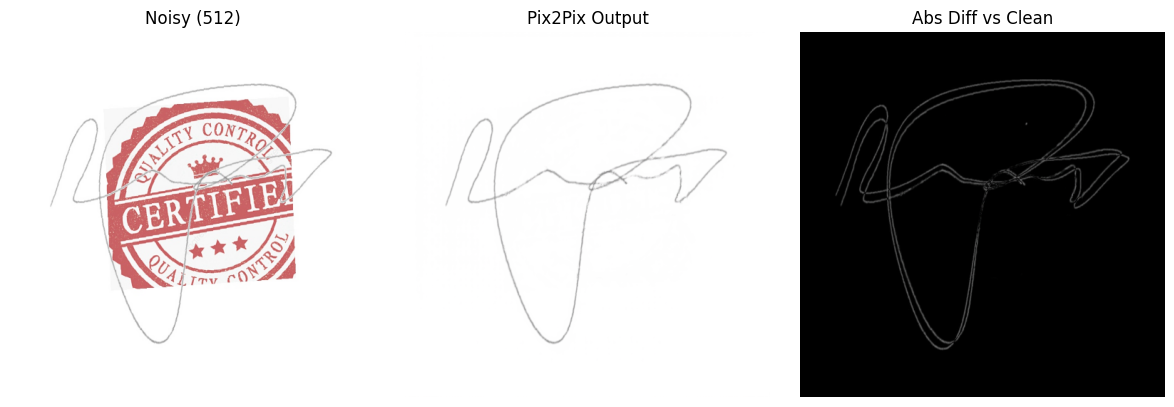

In [13]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

IMG_SIZE = (512, 512)

def load_rgb(path, img_size=IMG_SIZE):
    img = Image.open(path).convert("RGB")
    img = tf.image.resize(np.array(img), img_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img  # (512,512,3) float32 [0,1]

def to_m11(x01):  # [0,1] -> [-1,1]
    return x01 * 2.0 - 1.0

def to_01(xm11):  # [-1,1] -> [0,1]
    return (xm11 + 1.0) / 2.0

# paths
noisy_path = "/Users/sandeepsharma/Desktop/Signature/Test.png"  # your noisy image


# load & resize both to 512
x_noisy_01 = load_rgb(noisy_path)

# generator input
x = tf.expand_dims(to_m11(x_noisy_01), 0)   # (1,512,512,3)

y_pred = generator(x, training=False)       # (1,512,512,3) in [-1,1]
y_pred_01 = to_01(y_pred[0])                # (512,512,3) in [0,1]

diff = tf.abs(y_clean_01 - y_pred_01)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(x_noisy_01); plt.title("Noisy (512)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(y_pred_01);  plt.title("Pix2Pix Output"); plt.axis("off")
plt.tight_layout(); plt.show()

In [14]:
psnr = tf.image.psnr(y_clean_01, y_pred_01, max_val=1.0)
ssim = tf.image.ssim(y_clean_01, y_pred_01, max_val=1.0)

print("PSNR:", float(psnr.numpy()))
print("SSIM:", float(ssim.numpy()))

PSNR: 27.068214416503906
SSIM: 0.8972175717353821


# Cross-Model Demo: Load DeepLab + Pix2Pix generator

2026-02-05 12:00:43.941537: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 12:00:44.061983: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 12:00:44.851497: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 12:00:44.975193: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-05 12:00:46.539329: E external/local_xla/xla/service

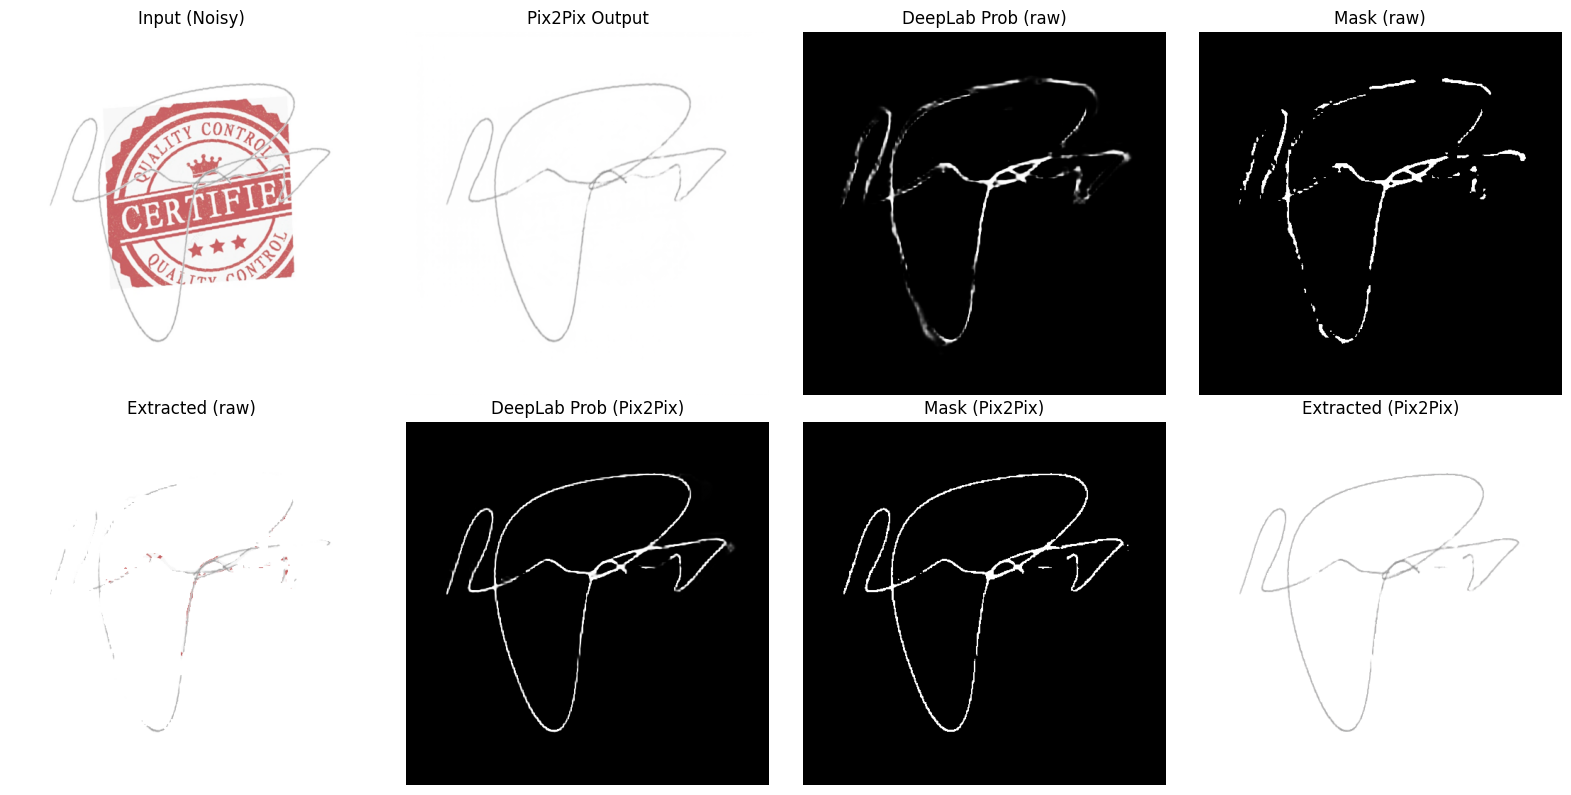

In [15]:
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

IMG_SIZE = (512, 512)

# -------- 1) Load saved models --------
deeplab = tf.keras.models.load_model("deeplab_best-2.keras", compile=False)
pix2pix_gen = tf.keras.models.load_model("pix2pix_gen_e3.keras", compile=False)  # change epoch file if needed

# -------- 2) Load image --------
img_path = "vault/3020/cf-3020-48.jpg"

def load_rgb_01(path, size=IMG_SIZE):
    img = Image.open(path).convert("RGB")
    img = img.resize(size, Image.BILINEAR)
    x = np.array(img).astype(np.float32) / 255.0  # [0,1]
    return x

x_noisy_01 = load_rgb_01(img_path)                            # (512,512,3)
x_noisy_m11 = x_noisy_01 * 2.0 - 1.0                          # [-1,1]
x_noisy_m11_b = np.expand_dims(x_noisy_m11, 0)                # (1,512,512,3)

# -------- 3) Pix2Pix -> cleaned image (RGB) --------
y_p2p_m11 = pix2pix_gen(x_noisy_m11_b, training=False)[0].numpy()  # (512,512,3) in [-1,1]
y_p2p_01  = (y_p2p_m11 + 1.0) / 2.0                                # (512,512,3) in [0,1]

# -------- 4) DeepLab on raw and on Pix2Pix output --------
thr = 0.35

prob_raw = deeplab.predict(np.expand_dims(x_noisy_01,0), verbose=0)[0,...,0]
mask_raw = (prob_raw >= thr).astype(np.uint8)

prob_p2p = deeplab.predict(np.expand_dims(y_p2p_01,0), verbose=0)[0,...,0]
mask_p2p = (prob_p2p >= thr).astype(np.uint8)

# -------- 5) Extract signature images (white BG) --------
def extract_white_bg(rgb01, mask01):
    out = (rgb01 * 255).astype(np.uint8).copy()
    out[mask01 == 0] = 255
    return out

extr_raw = extract_white_bg(x_noisy_01, mask_raw)
extr_p2p = extract_white_bg(y_p2p_01,  mask_p2p)

# -------- 6) Show results --------
plt.figure(figsize=(16,8))

plt.subplot(2,4,1); plt.imshow(x_noisy_01); plt.title("Input (Noisy)"); plt.axis("off")
plt.subplot(2,4,2); plt.imshow(y_p2p_01);   plt.title("Pix2Pix Output"); plt.axis("off")

plt.subplot(2,4,3); plt.imshow(prob_raw, cmap="gray"); plt.title("DeepLab Prob (raw)"); plt.axis("off")
plt.subplot(2,4,4); plt.imshow(mask_raw, cmap="gray"); plt.title("Mask (raw)"); plt.axis("off")

plt.subplot(2,4,5); plt.imshow(extr_raw); plt.title("Extracted (raw)"); plt.axis("off")
plt.subplot(2,4,6); plt.imshow(prob_p2p, cmap="gray"); plt.title("DeepLab Prob (Pix2Pix)"); plt.axis("off")
plt.subplot(2,4,7); plt.imshow(mask_p2p, cmap="gray"); plt.title("Mask (Pix2Pix)"); plt.axis("off")
plt.subplot(2,4,8); plt.imshow(extr_p2p); plt.title("Extracted (Pix2Pix)"); plt.axis("off")

plt.tight_layout(); plt.show()

In [16]:
import tensorflow as tf

psnr = tf.image.psnr(y_clean_01, y_pred_01, max_val=1.0)
ssim = tf.image.ssim(y_clean_01, y_pred_01, max_val=1.0)

print("PSNR:", float(psnr.numpy()))
print("SSIM:", float(ssim.numpy()))

PSNR: 27.068214416503906
SSIM: 0.8972175717353821
